In [21]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy import units as u
from galaxy_generation import generate_galaxy_multiple
import agama
import torch
# set agama unit to be in Msun, kpc, km/s
agama.setUnits(mass=1 * u.Msun, length=1*u.kpc, velocity=1 * u.km /u.s)
agama.setRandomSeed(100)

## Generate mock data from a galaxy model

We first define the galaxy model in Agama. This consists of:

1. A spheroidal dark matter halo potential. We will use the generalized NFW profile, which has a density profile given by:
$$\rho(r) = \frac{\rho_0}{(r/r_s)^\gamma (1 + (r/r_s)^\alpha)^{(\beta - \gamma)/\alpha}}$$

where $\rho_0$ is the density normalization, $r_s$ is the scale radius, $\beta$ is the outer slope, $\gamma$ is the inner slope, and $\alpha$ controls the transition between the inner and outer slopes. We will fix $\alpha=1$ and $\beta=3$, and vary the rest.

2. A stellar core. We will use a Plummer sphere, which has a density profile given by:
$$\nu_\star(r) = \frac{3M}{4\pi r_\star^3} \left(1 + \frac{r^2}{r_\star^2}\right)^{-5/2}$$

3. An isotropic distribution function

In [23]:
# Parameters
gamma = 1.0 # dm inner slope
r_dm = 1.0 # dm scale radius in kpc
rho_s = 1e7 # dm density normalization in Msun/kpc^3
r_star = 0.2 # stellar scale radius in kpc

# Define
# 1. the potential for the dark matter halo using a spheroidal model
# 2. the density for the stellar component using a Plummer model
# 3. the distribution function for the stellar component using a quasi-spherical model
dm_potential = agama.Potential(
    type="Spheroid", alpha=1, beta=3, gamma=gamma, scaleRadius=r_dm, densityNorm=rho_s)
stellar_density = agama.Density(
    type="Plummer", mass=1, scaleRadius=r_star)
dist_function = agama.DistributionFunction(
    type="QuasiSpherical", potential=dm_potential, density=stellar_density,
    beta0=0.0, r_a=np.inf)

# Put everything together in a galaxy model
galaxy_model = agama.GalaxyModel(dm_potential, dist_function)

Now we will generate mock data from this model. We will sample 100,000 stars from the distribution function. 

In [24]:
num_stars = 100_000
posvel, _ = galaxy_model.sample(num_stars)  # this returns (posvel, mass) but we ignore the
pos, vel = posvel[:, :3], posvel[:, 3:]

# Since we only observe the projected positions and line-of-sight velocities,
# we will only keep the x and y coordinates of the positions and the z component of the velocities.
r_proj = np.sqrt(pos[:, 0]**2 + pos[:, 1]**2)
v_los = vel[:, 2]

In [32]:
torch.poisson(torch.tensor([100], dtype=torch.float32)).long()

tensor([93])

## Plot

alpha, beta, gamma, log(p_0), log(r_s), log(r_star/r_s), log(r_a / r_star), beta_0

In [22]:
theta = torch.tensor([[1.0, 3.0, 0.0, 7.0, 0.0, -0.7, 0.0, 0.999]])
x = generate_galaxy_multiple(theta, [1000], 1)
r_proj = np.sqrt(x[:, 0]**2 + x[:, 1]**2)
v_los = x[:, 2]

RuntimeError: Error in sample(): Error in sampleNdim: refinement procedure did not converge

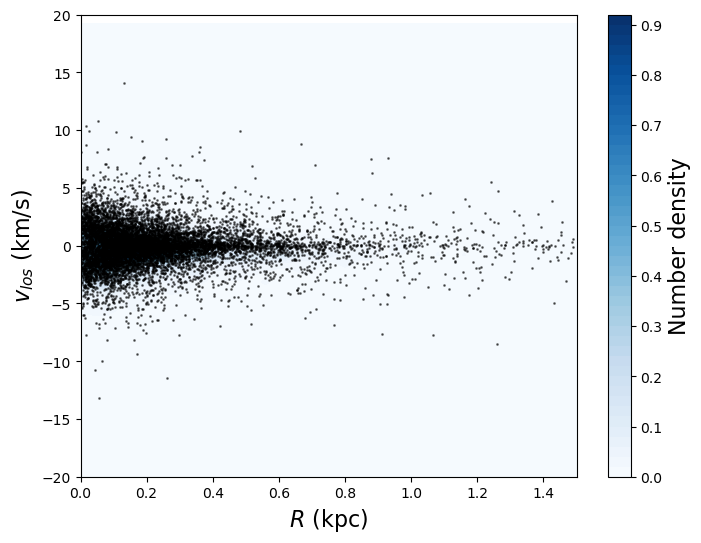

In [28]:
def plot_contour(r_proj, v_los, ax):
    """ calculate and plot the contour of the distribution function in the projected space """
    # calculate the grid
    r_grid = np.linspace(0, 2, 51)
    v_grid = np.linspace(-20, 20, 51)
    R, V = np.meshgrid(r_grid[:-1], v_grid[:-1])

    # number density in the projected space
    Z, _, _ = np.histogram2d(
        r_proj, v_los, bins=[r_grid, v_grid], density=True)

    # plot the contour
    contourf = ax.contourf(
        R, V, Z.T, levels=50, cmap="Blues")

    # add colorbar to show the density scale
    cbar = plt.colorbar(contourf, ax=ax)

    return ax, cbar

fig, ax = plt.subplots(figsize=(8, 6))
ax, cbar = plot_contour(r_proj, v_los, ax)
ax.scatter(r_proj, v_los, s=1, color='k', alpha=0.5)
ax.set_xlim(0, 1.5)
ax.set_ylim(-20, 20)
ax.set_xlabel(r"$R$ (kpc)", fontsize=16)
ax.set_ylabel(r"$v_{los}$ (km/s)", fontsize=16)
# ax.set_title(
#     r"$\gamma={}; r_s={:.1f} \ \mathrm{{kpc}}; \rho_s={:.1e} \ \mathrm{{M_\odot/kpc^3}}$".format(
#         gamma, r_dm, rho_s), fontsize=16)
cbar.set_label("Number density", fontsize=16)

plt.show()

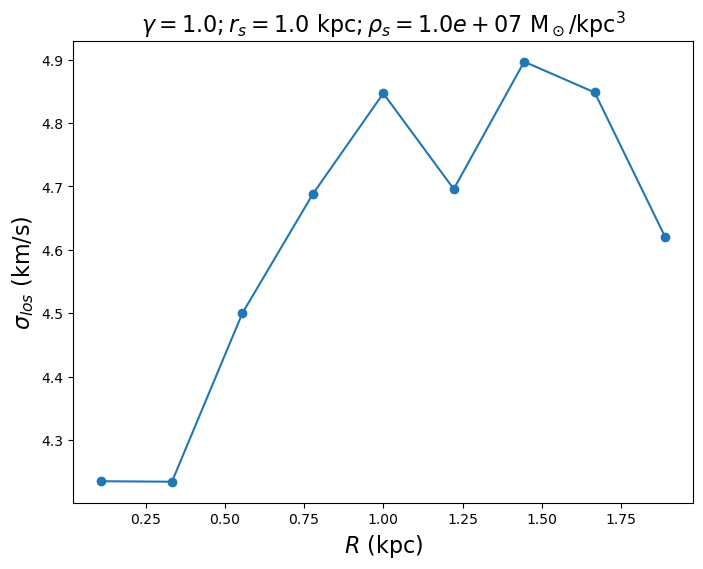

In [ ]:
# Calculate the velocity dispersion profile sigma_los(R)
def calc_los_dispersion(r_proj, v_los, r_bins):
    """ calculate the line-of-sight velocity dispersion profile in bins of projected radius """
    sigma_los = []
    for i in range(len(r_bins)-1):
        mask = (r_proj >= r_bins[i]) & (r_proj < r_bins[i+1])
        sigma_los.append(np.std(v_los[mask]))
    return np.array(sigma_los)

r_bins = np.linspace(0, 2, 10)
sigma_los = calc_los_dispersion(r_proj, v_los, r_bins)
r_center = 0.5*(r_bins[:-1]+r_bins[1:])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(r_center, sigma_los, marker='o')
ax.set_xlabel(r"$R$ (kpc)", fontsize=16)
ax.set_ylabel(r"$\sigma_{los}$ (km/s)", fontsize=16)
ax.set_title(
    r"$\gamma={}; r_s={:.1f} \ \mathrm{{kpc}}; \rho_s={:.1e} \ \mathrm{{M_\odot/kpc^3}}$".format(
        gamma, r_dm, rho_s), fontsize=16)
plt.show()